# Astronomy Supervised - Acquire and preprocess data

This reference notebook records the preprocessing work to convert the MMU PLAsTiCC
light curve data into a format suitable for training a supervised classifier.

## Overview

The workflow is:

- Download the PLAsTiCC light-curve dataset from the Multi-Modal Universe project
- Process the raw light curve data into a format suitable for training
- (*Next notebook*) Download the preprocessed data and class mapping from Zenodo
- (*Next notebook*) Define a custom Hyrax dataset
- (*Next notebook*) Define a Gated Recurrent Unit (GRU)-based recurrent model
- (*Next notebook*) Train the classifier on the training set
- (*Next notebook*) Predict transient classes on held-out test data
- (*Next notebook*) Evaluate performance with a confusion matrix

## The data

This example uses the [PLAsTiCC](https://plasticc.org/) training set as reformatted by the
[Multi-Modal Universe](https://github.com/MultimodalUniverse/MultimodalUniverse) (MMU) project.
It contains roughly 7,800 labeled light curves across 14 classes of astronomical transients
and variables — including SNIa, SNII, SNIbc, TDE, AGN, RR Lyrae, kilonova, and more.
Each light curve has multi-band photometry (LSST *ugrizY*) with irregular cadence.


## Download the data from HuggingFace

In [ ]:
%pip install datasets

In [1]:
from datasets import load_dataset

ds = load_dataset("MultimodalUniverse/plasticc", split="train")

print(f"Loaded {len(ds)} samples")
print(f"\nFeatures: {list(ds.features.keys())}")
print(f"\nFirst sample keys: {list(ds[0].keys())}")
print(f"Light curve keys:  {list(ds[0]['lightcurve'].keys())}")

Loaded 7848 samples

Features: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']

First sample keys: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']
Light curve keys:  ['band', 'flux', 'flux_err', 'time']


## Preprocess light curves

The raw light curves have variable lengths and irregular cadence across six LSST bands.
Instead of binning into a fixed grid (which destroys temporal structure), we keep every
observation and represent it as a feature vector that a recurrent model can consume directly.

For each object we:
1. Filter out zero-padded placeholder observations
2. Sort all observations chronologically (across all bands)
3. Compute the time elapsed since the previous observation (delta-t)
4. Normalize flux per object
5. One-hot encode the photometric band

This produces a variable-length sequence of 9-dimensional feature vectors per object:
`(delta_t, flux, flux_err, u, g, r, i, z, Y)`.

In [ ]:
import json
import numpy as np
from pathlib import Path

# LSST band names in wavelength order → channel indices
BAND_TO_IDX = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "Y": 5}
NUM_BANDS = len(BAND_TO_IDX)
INPUT_DIM = 1 + 1 + 1 + NUM_BANDS  # delta_t, flux, flux_err, 6 band one-hots = 9


def extract_sequence(lc):
    """Convert a variable-length multi-band light curve into a feature sequence.

    Returns an (N_obs, 9) float32 array where each row is
    (delta_t, flux, flux_err, u, g, r, i, z, Y).
    """
    band_strs = np.asarray(lc["band"])
    times = np.asarray(lc["time"], dtype=np.float64)
    fluxes = np.asarray(lc["flux"], dtype=np.float32)
    flux_errs = np.asarray(lc["flux_err"], dtype=np.float32)

    # The MMU PLAsTiCC format zero-pads unused observation slots.
    real = (times > 0) | (fluxes != 0)
    band_strs, times, fluxes, flux_errs = (
        band_strs[real],
        times[real],
        fluxes[real],
        flux_errs[real],
    )

    if len(times) == 0:
        return np.zeros((1, INPUT_DIM), dtype=np.float32)

    # Sort chronologically
    order = np.argsort(times)
    band_strs, times, fluxes, flux_errs = (
        band_strs[order],
        times[order],
        fluxes[order],
        flux_errs[order],
    )

    # Delta-t: time since previous observation (first obs gets 0)
    delta_t = np.zeros(len(times), dtype=np.float32)
    delta_t[1:] = np.diff(times).astype(np.float32)
    # Normalize delta_t to [0, 1]
    dt_max = delta_t.max()
    if dt_max > 0:
        delta_t /= dt_max

    # Normalize flux per object
    max_abs = np.abs(fluxes).max()
    if max_abs > 0:
        fluxes /= max_abs
        flux_errs /= max_abs

    # One-hot band encoding
    band_onehot = np.zeros((len(times), NUM_BANDS), dtype=np.float32)
    for j, bs in enumerate(band_strs):
        idx = BAND_TO_IDX.get(str(bs), -1)
        if idx >= 0:
            band_onehot[j, idx] = 1.0

    # Stack into (N_obs, 9) feature matrix
    seq = np.column_stack([delta_t, fluxes, flux_errs, band_onehot])
    return seq.astype(np.float32)


# --- Process every sample ---
all_seqs, all_raw_labels = [], []
for sample in ds:
    all_seqs.append(extract_sequence(sample["lightcurve"]))
    all_raw_labels.append(sample["obj_type"])

# Map string labels to contiguous integers
unique_classes = sorted(set(all_raw_labels))
label_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_name = {i: c for i, c in enumerate(unique_classes)}
labels = np.array([label_to_idx[l] for l in all_raw_labels])

seq_lengths = [len(s) for s in all_seqs]
print(f"Preprocessed {len(all_seqs)} light curves")
print(
    f"Sequence lengths: min={min(seq_lengths)}, median={int(np.median(seq_lengths))}, max={max(seq_lengths)}"
)
print(f"Feature dim: {INPUT_DIM}")
print(f"\nClasses: {len(unique_classes)}")
for i, name in idx_to_name.items():
    count = (labels == i).sum()
    print(f"  {i:>2d}: {name} ({count} samples)")

# --- Compute class weights (inverse frequency) for weighted loss ---
class_counts = np.bincount(labels)
class_weights = len(labels) / (len(unique_classes) * class_counts)
class_weights = class_weights.astype(np.float32)
print(f"\nClass weights: {dict(zip(idx_to_name.values(), class_weights.round(2)))}")

# --- 80/20 stratified train/test split ---
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

data_dir = Path("./data/plasticc")
data_dir.mkdir(parents=True, exist_ok=True)

# Save sequences as object arrays (variable length) + labels + class weights
np.savez(
    data_dir / "train.npz",
    sequences=np.array([all_seqs[i] for i in train_idx], dtype=object),
    labels=labels[train_idx],
    object_ids=train_idx,
    class_weights=class_weights,
)
np.savez(
    data_dir / "test.npz",
    sequences=np.array([all_seqs[i] for i in test_idx], dtype=object),
    labels=labels[test_idx],
    object_ids=test_idx,
)

# Save the class index to name mapping for later interpretation. Note that the
# keys will be strings in JSON. We'll convert them back to integers when loading.
with open(data_dir / "idx_to_name.json", "w") as f:
    json.dump(idx_to_name, f)

print(f"\nSaved {len(train_idx)} train / {len(test_idx)} test samples to {data_dir}")

Preprocessed 7848 light curves
Sequence lengths: min=34, median=100, max=296
Feature dim: 9

Classes: 14
   0: AGN (370 samples)
   1: EB (924 samples)
   2: KN (102 samples)
   3: M-dwarf (981 samples)
   4: MicroLens-Single (151 samples)
   5: Mira (30 samples)
   6: RRL (239 samples)
   7: SLSN-I (175 samples)
   8: SNII (1193 samples)
   9: SNIa (2313 samples)
  10: SNIa-91bg (208 samples)
  11: SNIax (183 samples)
  12: SNIbc (484 samples)
  13: TDE (495 samples)

Class weights: {'AGN': np.float32(1.52), 'EB': np.float32(0.61), 'KN': np.float32(5.5), 'M-dwarf': np.float32(0.57), 'MicroLens-Single': np.float32(3.71), 'Mira': np.float32(18.69), 'RRL': np.float32(2.35), 'SLSN-I': np.float32(3.2), 'SNII': np.float32(0.47), 'SNIa': np.float32(0.24), 'SNIa-91bg': np.float32(2.7), 'SNIax': np.float32(3.06), 'SNIbc': np.float32(1.16), 'TDE': np.float32(1.13)}

Saved 6278 train / 1570 test samples to data/plasticc


## Plot some examples

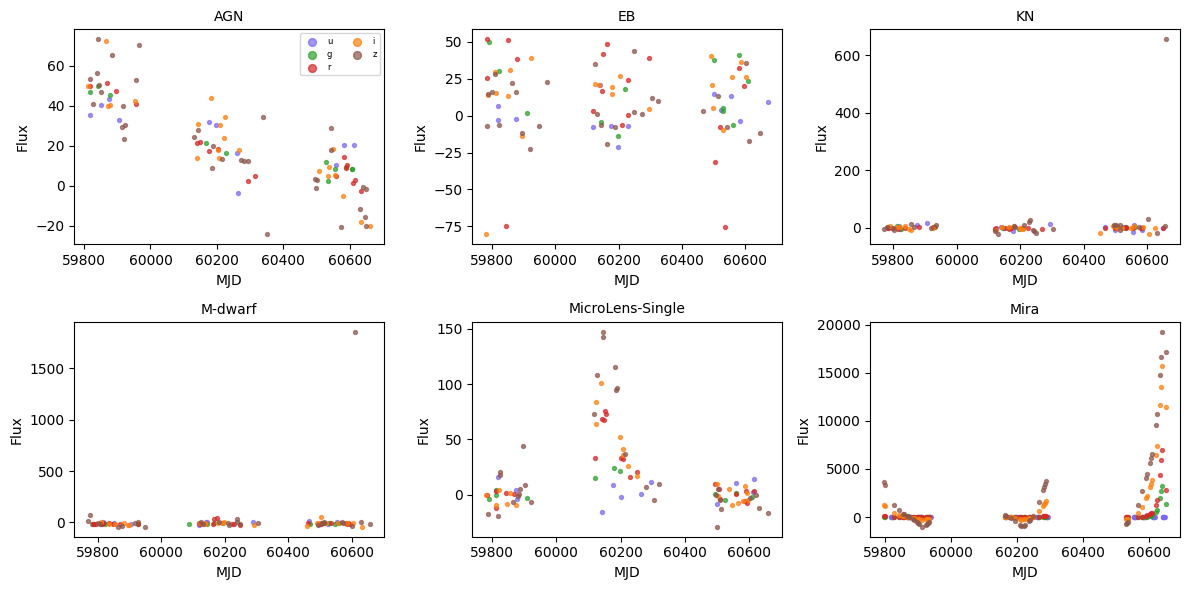

In [3]:
import numpy as np
import matplotlib.pyplot as plt

BAND_TO_IDX = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "Y": 5}
BAND_NAMES = list(BAND_TO_IDX.keys())
band_colors = {"u": "#7B68EE", "g": "#2ca02c", "r": "#d62728", "i": "#ff7f0e", "z": "#8c564b", "Y": "#1f77b4"}

show_classes = list(range(min(6, len(idx_to_name))))
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, cls in zip(axes.flat, show_classes):
    sample_idx = np.where(labels == cls)[0][0]
    lc = ds[int(sample_idx)]["lightcurve"]

    band_strs = np.asarray(lc["band"])
    times = np.asarray(lc["time"], dtype=np.float64)
    fluxes = np.asarray(lc["flux"], dtype=np.float32)
    real = (times > 0) | (fluxes != 0)

    for band_name in BAND_NAMES:
        mask = real & (band_strs == band_name)
        if mask.any():
            ax.scatter(
                times[mask],
                fluxes[mask],
                label=band_name,
                c=band_colors[band_name],
                s=8,
                alpha=0.7,
            )
    ax.set_title(idx_to_name[cls], fontsize=10)
    ax.set_xlabel("MJD")
    ax.set_ylabel("Flux")

axes[0, 0].legend(fontsize=6, ncol=2, markerscale=2)
plt.tight_layout()
plt.show()